# 01 - EDA: RGM product segmentatin

Weekly panel, grain = `rgm_ppg x retailer x week`. Goal here is just to
understand the data well enough to justify the feature choices in
`src/features.py` — not to draw conclusions yet.

In [15]:
import pandas as pd

df = pd.read_csv("../data/raw/ECON_POS_anonymized.csv", low_memory=False)
print(df.shape)
print(df.dtypes)

(84550, 54)
retailer_nm                            str
rgm_ppg                                str
period_id                              str
channel_nm                             str
manufacturer_nm                        str
attribute_1                            str
attribute_2                            str
attribute_3                            str
attribute_4                            str
attribute_5                            str
attribute_6                            str
attribute_7                            str
attribute_8                            str
attribute_9                            str
ppg_attr1                              str
ppg_attr2                              str
ppg_attr3                              str
ppg_attr4                              str
ppg_attr5                              str
ppg_attr6                              str
ppg_attr7                              str
ppg_attr8                              str
ppg_attr9                            int64

## Key counts

In [16]:
for col in ["retailer_nm", "rgm_ppg", "product_id", "category", "subcategory_nm", "brand_nm"]:
    print(col, df[col].nunique())

retailer_nm 6
rgm_ppg 366
product_id 43
category 1
subcategory_nm 6
brand_nm 17


`product_id` is not reliable as a unique key. Values like '8.01E+12' are stored as scientific-notation strings, probably rounded during an Excel export. This means different EAN/SKU codes can end up with the same value, so the number of unique products is underestimated. Using rgm_ppg as the segmentation level instead of product_id.

In [17]:
df["product_id"].apply(type).value_counts()
df["product_id"].head(20).tolist()

['8.01E+12',
 '5.06E+12',
 '5.01E+12',
 '5.01E+12',
 '8.00E+12',
 '8.01E+12',
 '5.06E+12',
 '8.01E+12',
 '5.06E+12',
 '5.01E+12',
 '5.01E+12',
 '5.01E+12',
 '5.06E+12',
 '5.06E+12',
 '5.06E+12',
 '5.01E+12',
 '5.01E+12',
 '8.01E+12',
 '5.01E+12',
 '8.01E+12']

## Date range and missing values

In [18]:
df["period_id"] = pd.to_datetime(df["period_id"])
print(df["period_id"].min(), df["period_id"].max())

2022-12-03 00:00:00 2025-11-29 00:00:00


In [19]:
df.isna().mean().sort_values(ascending=False).head(15)

ppg_attr11                         1.0
ppg_attr10                         1.0
retailer_nm                        0.0
any_promo_units                    0.0
acv_tpr_only                       0.0
feature_and_display_acv_pct        0.0
feature_without_display_acv_pct    0.0
is_own_manufacturer                0.0
subcategory_nm                     0.0
uom                                0.0
product_unit_size                  0.0
subbrand_nm                        0.0
month_nm                           0.0
product_id                         0.0
brand_nm                           0.0
dtype: float64

`ppg_attr10` / `ppg_attr11` are 100% missing, safe to drop. Everything else in the core sales/promo fields is fully populated.

## Sales and promo field distribution

In [20]:
df[["total_units", "total_sales", "acv_pct", "any_promo_units", "any_promo_amt"]].describe()

,total_units,total_sales,acv_pct,any_promo_units,any_promo_amt
count,84550.000000,84550.000000,84550.000000,84550.000000,84550.000000
mean,2956.237741,10867.100824,29.594895,682.486858,4841.452400
std,4383.421480,20043.670651,34.682560,2246.539861,14755.663469
min,1000.910000,0.100000,0.000000,-1382.751200,-14459.070600
25%,1035.000000,240.000000,0.599325,0.000000,0.000000
50%,1466.000000,3356.920000,4.509150,10.699200,59.691050
75%,3040.000000,12196.970000,66.616575,335.084225,2268.607025
max,81495.000000,487140.850000,99.598600,80495.000000,487140.850000


**Negative values in `any_promo_units` / `any_promo_amt`** shouldn't be possible for a promo-units/amount field

In [21]:
neg = df[(df["any_promo_units"] < 0) | (df["any_promo_amt"] < 0)]
print(len(neg), "rows with negative promo values —", round(len(neg) / len(df) * 100, 3), "% of data")
neg[["rgm_ppg", "period_id", "any_promo_units", "any_promo_amt"]]

14 rows with negative promo values — 0.017 % of data


,rgm_ppg,period_id,any_promo_units,any_promo_amt
5820,PPG_ATTR1_F6394E71 | PPG_ATTR2_2BEF0FAC | PPG_...,2024-07-13,-27.6918,-329.9835
13239,PPG_ATTR1_F6394E71 | PPG_ATTR2_2BEF0FAC | PPG_...,2023-03-25,-122.9010,-140.7709
22104,PPG_ATTR1_DE0C4AF4 | PPG_ATTR2_2BEF0FAC | PPG_...,2023-02-18,-44.0712,-97.3718
29355,PPG_ATTR1_DE0C4AF4 | PPG_ATTR2_2BEF0FAC | PPG_...,2025-02-01,-38.4277,-167.6312
34596,PPG_ATTR1_DE0C4AF4 | PPG_ATTR2_2BEF0FAC | PPG_...,2022-12-10,-77.2437,-759.3007
39684,PPG_ATTR1_C8230F0F | PPG_ATTR2_2BEF0FAC | PPG_...,2023-07-22,-88.4878,-488.6800
43032,PPG_ATTR1_DE0C4AF4 | PPG_ATTR2_2BEF0FAC | PPG_...,2025-11-08,0.0000,-12939.6902
51102,PPG_ATTR1_DE0C4AF4 | PPG_ATTR2_2BEF0FAC | PPG_...,2024-05-11,-0.3810,18.7654
53180,PPG_ATTR1_F6394E71 | PPG_ATTR2_2BEF0FAC | PPG_...,2023-07-22,-10.2659,-61.2004
54994,PPG_ATTR1_DE0C4AF4 | PPG_ATTR2_2BEF0FAC | PPG_...,2023-05-27,-1382.7512,-14459.0706


Only 14 rows (0.02%) — likely retroactive corrections/returns. Too rare to drop the rows (would lose otherwise-valid `total_units`/`total_sales`), so clip the two promo fields at 0 before aggregating in `features.py`.

In [22]:
df["any_promo_units"] = df["any_promo_units"].clip(lower=0)
df["any_promo_amt"] = df["any_promo_amt"].clip(lower=0)

## Weekly sales shape, sanity check on trend/seasonality

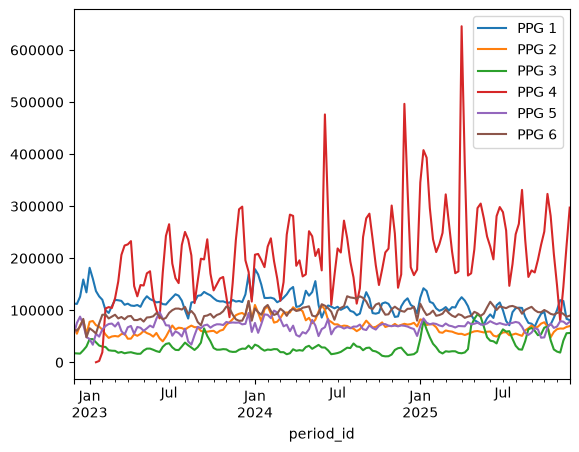

In [23]:
import matplotlib.pyplot as plt

sample_ppgs = df["rgm_ppg"].value_counts().head(6).index
for i, ppg in enumerate(sample_ppgs):
    sub = df[df["rgm_ppg"] == ppg].groupby("period_id")["total_sales"].sum()
    sub.plot(label=f"PPG {i+1}")
plt.legend()
plt.show()

## Distribution strength (ACV)

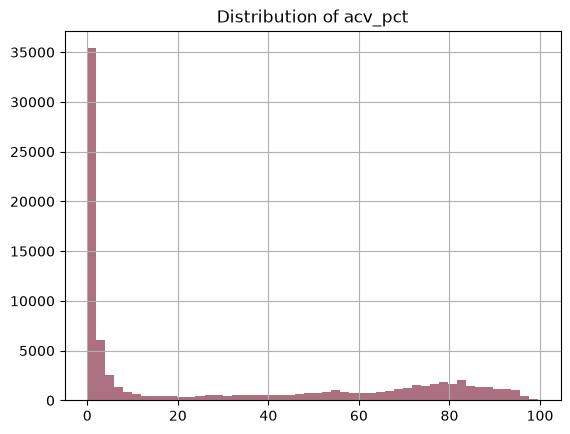

In [24]:
df["acv_pct"].hist(bins=50, color="#AC7080")
plt.title("Distribution of acv_pct")
plt.show()

This is bimodal, not just skewed. Most PPGs are either close to 0 distribution or somewhere between 55–95%, with not much in between. It looks like products are either barely distributed or widely available. Because of that, `avg_acv` should be a useful feature for separating these groups.

## Promo mechanic mix by retailer

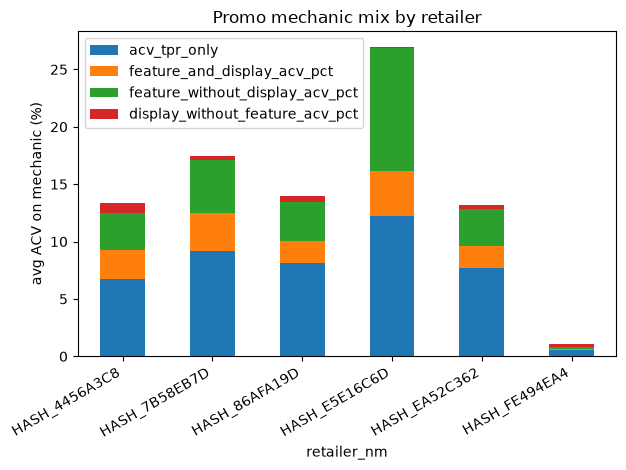

In [25]:
promo_cols = [
    "acv_tpr_only",
    "feature_and_display_acv_pct",
    "feature_without_display_acv_pct",
    "display_without_feature_acv_pct",
]
mix = df.groupby("retailer_nm")[promo_cols].mean()
mix.plot(kind="bar", stacked=True)
plt.ylabel("avg ACV on mechanic (%)")
plt.title("Promo mechanic mix by retailer")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Price distribution

In [26]:
df["price"] = df["total_sales"] / df["total_units"].replace(0, pd.NA)
df["price"].describe()

count    84550.000000
mean         2.576040
std          2.659529
min          0.000100
25%          0.229413
50%          1.858089
75%          4.030048
max         26.975051
Name: price, dtype: float64

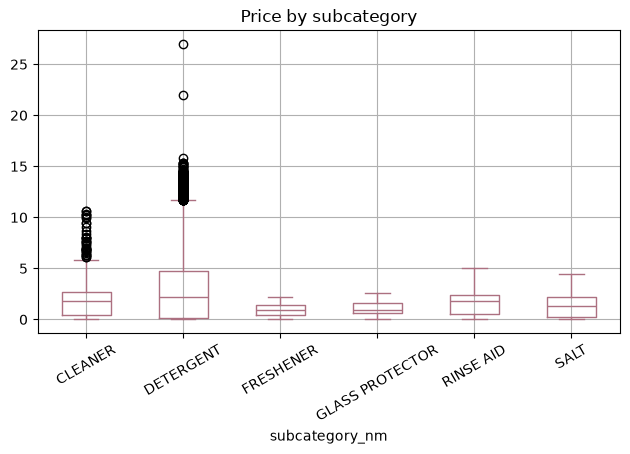

In [27]:
df.boxplot(column="price", by="subcategory_nm", rot=30, color="#AC7080")
plt.suptitle("")
plt.title("Price by subcategory")
plt.tight_layout()
plt.show()

## Quick correlation check across core numeric fields

In [28]:
core = ["total_units", "total_sales", "acv_pct", "any_promo_units", "any_promo_amt", "price"]
corr = df[core].corr()
corr

,total_units,total_sales,acv_pct,any_promo_units,any_promo_amt,price
total_units,1.000000,0.790851,0.491259,0.532778,0.439748,0.278933
total_sales,0.790851,1.000000,0.516557,0.683295,0.787606,0.645953
acv_pct,0.491259,0.516557,1.000000,0.341741,0.344828,0.536270
any_promo_units,0.532778,0.683295,0.341741,1.000000,0.869498,0.348662
any_promo_amt,0.439748,0.787606,0.344828,0.869498,1.000000,0.519620
price,0.278933,0.645953,0.536270,0.348662,0.519620,1.000000
